In [35]:
import math
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [36]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [37]:
warnings.filterwarnings('ignore')

In [38]:
df = pd.read_csv('data/club-rankings-ext/Matches.csv')

In [39]:
df = df[df['MatchDate'] >= '2016-01-01']

In [40]:
df = df[['Division', 'MatchDate', 'HomeTeam', 'AwayTeam', 'HomeElo', 'AwayElo', 'Form5Home', 'Form5Away', 'FTResult', 'OddHome', 'OddDraw', 'OddAway']]

In [41]:
new_df = pd.read_csv('data/club-rankings-ext/matches-with-opta-rankings_v2.csv')

In [42]:
df = df.merge(new_df[['MatchDate', 'HomeTeam', 'predicted_elo_home', 'predicted_elo_away']], on=['MatchDate', 'HomeTeam'], how='inner')
df.dropna(inplace=True)

In [43]:
df.drop(columns=['HomeElo', 'AwayElo'], inplace=True)
df.rename(columns={'predicted_elo_home': 'HomeElo', 'predicted_elo_away': 'AwayElo'}, inplace=True)
df.describe()

,Form5Home,Form5Away,OddHome,OddDraw,OddAway,HomeElo,AwayElo
count,3469.000000,3469.000000,3469.000000,3469.000000,3469.000000,3469.000000,3469.000000
mean,6.905448,7.083309,2.610899,3.874402,4.072078,1567.477544,1566.462269
std,3.351951,3.322485,1.498497,1.055325,2.827753,153.217422,152.438112
min,0.000000,0.000000,1.050000,2.110000,1.090000,1154.630000,1161.330000
25%,4.000000,5.000000,1.750000,3.280000,2.450000,1453.880000,1453.880000
50%,7.000000,7.000000,2.230000,3.550000,3.270000,1549.900000,1549.900000
75%,9.000000,10.000000,2.900000,4.040000,4.610000,1672.730000,1672.730000
max,15.000000,15.000000,22.050000,14.180000,27.070000,1994.310000,1994.310000


In [44]:
df.shape

(3469, 12)

In [45]:
df = df[(df['OddHome'] > 1) & (df['OddDraw'] > 1) & (df['OddAway'] > 1)]
df.dropna(inplace=True)
df.shape

(3469, 12)

In [46]:
df['FTResult'].value_counts() / df.shape[0]

FTResult
H    0.435860
A    0.302104
D    0.262035
Name: count, dtype: float64

In [47]:
original_df = df.copy()

In [48]:
df.groupby('Division').size()

Division
AUT     18
B1     165
D1     180
D2      75
DEN     55
E0     335
E1     381
F1     323
F2     219
G1      51
I1     372
I2     187
N1      75
NOR     35
P1     137
RUS      7
SC0    171
SP1    275
SP2    262
SWE     45
T1     101
dtype: int64

In [49]:
# pdf = df[df['Division'].isin(['AUT', 'B1', 'D2', 'DEN', 'F2', 'G1', 'I2', 'NOR', 'POL', 'SP2', 'SWE'])].copy()
# pdf = df[df['Division'].isin(['D1', 'E1', 'F1', 'I1', 'SC0', 'SP1'])].copy()
# pdf = pdf[pdf['Division'].isin(['POL'])].copy()
pdf = df.copy()
pdf.shape

(3469, 12)

In [50]:
def calculate_probabilities(row, HFA=60, NU=1.6):
    home_elo = row['HomeElo'] # + row['Form5Home'] * 5
    away_elo = row['AwayElo'] # + row['Form5Away'] * 5
    elo_difference = home_elo - away_elo + HFA

    p_win_base = 1 / (1 + math.pow(10, -elo_difference / 400))
    denom = 1 + NU * p_win_base * (1 - p_win_base)
    pH = p_win_base / denom
    pA = (1 - p_win_base) / denom
    pD = 1 - pH - pA

    return [pH, pD, pA]

In [51]:
pdf[['ProbHome', 'ProbDraw', 'ProbAway']] = pdf.apply(calculate_probabilities, axis=1, result_type='expand')

In [52]:
pdf['Hold'] = 1 / pdf['OddHome'] + 1 / pdf['OddDraw'] + 1 / pdf['OddAway'] - 1

In [53]:
pdf = pdf[pdf['Hold'] <= 0.08]
pdf.shape

(3465, 16)

In [54]:
pdf['ImpliedProbHome'] = 1 / pdf['OddHome'] / (1 + pdf['Hold'])
pdf['ImpliedProbDraw'] = 1 / pdf['OddDraw'] / (1 + pdf['Hold'])
pdf['ImpliedProbAway'] = 1 / pdf['OddAway'] / (1 + pdf['Hold'])

In [55]:
pdf['EV_Home'] = pdf['ProbHome'] * pdf['OddHome']
pdf['EV_Draw'] = pdf['ProbDraw'] * pdf['OddDraw']
pdf['EV_Away'] = pdf['ProbAway'] * pdf['OddAway']

In [56]:
for col in ['ProbHome', 'ProbDraw', 'ProbAway', 'Hold', 'EV_Home', 'EV_Draw', 'EV_Away']:
    pdf[col] = pdf[col].round(5)

In [57]:
def place_bet(row):
    best_prob = max(row['EV_Home'], row['EV_Draw'], row['EV_Away'])
    if row['EV_Home'] == best_prob:
        return 'H'
    elif row['EV_Away'] == best_prob:
        return 'A'
    elif row['EV_Draw'] == best_prob:
        return 'D'

pdf['BetPlaced'] = pdf.apply(place_bet, axis=1)

In [58]:
pdf['BetPlaced'].value_counts()

BetPlaced
A    1723
H    1366
D     376
Name: count, dtype: int64

In [59]:
pdf.head()

,Division,MatchDate,HomeTeam,AwayTeam,Form5Home,Form5Away,FTResult,OddHome,OddDraw,OddAway,HomeElo,AwayElo,ProbHome,ProbDraw,ProbAway,Hold,ImpliedProbHome,ImpliedProbDraw,ImpliedProbAway,EV_Home,EV_Draw,EV_Away,BetPlaced
0,E0,2024-02-20,Man City,Brentford,13.0,6.0,H,1.18,8.12,15.16,1994.31,1690.60,0.76996,0.13516,0.09488,0.03657,0.817557,0.118808,0.063636,0.90855,1.09748,1.43844,A
1,E1,2024-02-20,Cardiff,Blackburn,3.0,5.0,D,2.89,3.27,2.49,1413.68,1429.31,0.40437,0.28241,0.31322,0.05344,0.328468,0.290298,0.381234,1.16863,0.92347,0.77993,H
2,E1,2024-02-20,Southampton,Hull,12.0,12.0,A,1.54,4.46,5.56,1594.57,1482.91,0.55362,0.24029,0.20609,0.05342,0.616420,0.212845,0.170735,0.85257,1.07171,1.14587,A
3,E0,2024-02-21,Liverpool,Luton,12.0,5.0,H,1.20,7.72,13.14,1911.68,1599.04,0.77838,0.13051,0.09112,0.03897,0.802076,0.124675,0.073249,0.93405,1.00752,1.19725,A
4,I1,2024-02-22,Torino,Lazio,9.0,7.0,A,2.47,2.94,3.29,1674.96,1739.73,0.35226,0.28568,0.36207,0.04895,0.385967,0.324265,0.289768,0.87008,0.83989,1.19119,A


In [60]:
pdf.describe()

,Form5Home,Form5Away,OddHome,OddDraw,OddAway,HomeElo,AwayElo,ProbHome,ProbDraw,ProbAway,Hold,ImpliedProbHome,ImpliedProbDraw,ImpliedProbAway,EV_Home,EV_Draw,EV_Away
count,3465.000000,3465.000000,3465.000000,3465.000000,3465.000000,3465.000000,3465.000000,3465.000000,3465.000000,3465.000000,3465.000000,3465.000000,3465.000000,3465.000000,3465.000000,3465.000000,3465.000000
mean,6.907359,7.086869,2.610938,3.875377,4.073359,1567.719532,1566.697937,0.432565,0.255196,0.312238,0.056141,0.436208,0.256130,0.307662,0.969795,0.953562,1.017601
std,3.352262,3.320750,1.499256,1.055541,2.829076,153.133001,152.365534,0.142957,0.039314,0.124854,0.010170,0.161716,0.046347,0.145073,0.162160,0.108224,0.211536
min,0.000000,0.000000,1.050000,2.110000,1.090000,1154.630000,1161.330000,0.083690,0.060080,0.039180,0.036570,0.043044,0.066540,0.034855,0.412390,0.452790,0.380720
25%,4.000000,5.000000,1.750000,3.290000,2.450000,1453.880000,1453.880000,0.338760,0.244240,0.231610,0.046980,0.327253,0.235347,0.205282,0.868780,0.883980,0.875120
50%,7.000000,7.000000,2.230000,3.560000,3.270000,1549.900000,1549.900000,0.419240,0.271160,0.300630,0.055220,0.424021,0.266661,0.288691,0.942300,0.942580,0.982730
75%,9.000000,10.000000,2.900000,4.040000,4.610000,1672.730000,1672.730000,0.513070,0.282320,0.376090,0.064600,0.539368,0.288077,0.387409,1.040450,1.010070,1.115810
max,15.000000,15.000000,22.050000,14.180000,27.070000,1994.310000,1994.310000,0.900740,0.285710,0.795150,0.078850,0.898605,0.444170,0.870751,2.351900,1.531800,2.293740


In [61]:
def strategy_flat_elo(row, min_cutoff=1, max_cutoff=3):
    bet_size = 1
    result = None
    
    if pd.isna(row['BetPlaced']):
        return None, None
    if max(row['EV_Home'], row['EV_Draw'], row['EV_Away']) < min_cutoff:
        return None, None
    if max(row['EV_Home'], row['EV_Draw'], row['EV_Away']) > max_cutoff:
        return None, None

    if row['BetPlaced'] == row['FTResult']:
        if row['BetPlaced'] == 'H':
            result = bet_size * (row['OddHome'] - 1)
        elif row['BetPlaced'] == 'D':
            result = bet_size * (row['OddDraw'] - 1)
        elif row['BetPlaced'] == 'A':
            result = bet_size * (row['OddAway'] - 1)
    else:
        result = -bet_size

    return result, bet_size

In [62]:
def strategy_dynamic_elo(row, min_cutoff=1, max_cutoff=3):
    bet_size = 1
    result = None
    
    if pd.isna(row['BetPlaced']):
        return None, None
    if max(row['EV_Home'], row['EV_Draw'], row['EV_Away']) < min_cutoff:
        return None, None
    if max(row['EV_Home'], row['EV_Draw'], row['EV_Away']) > max_cutoff:
        return None, None

    if max(row['EV_Home'], row['EV_Draw'], row['EV_Away']) == row['EV_Home']:
        bet_size = 1 / row['OddHome']
    elif max(row['EV_Home'], row['EV_Draw'], row['EV_Away']) == row['EV_Draw']:
        bet_size = 1 / row['OddDraw']
    elif max(row['EV_Home'], row['EV_Draw'], row['EV_Away']) == row['EV_Away']:
        bet_size = 1 / row['OddAway']

    if row['BetPlaced'] == row['FTResult']:
        if row['BetPlaced'] == 'H':
            result = bet_size * (row['OddHome'] - 1)
        elif row['BetPlaced'] == 'D':
            result = bet_size * (row['OddDraw'] - 1)
        elif row['BetPlaced'] == 'A':
            result = bet_size * (row['OddAway'] - 1)
    else:
        result = -bet_size

    return result, bet_size

In [63]:
def strategy_flat_home_v2(row):
    bet_size = 1
    result = None
    
    threshold = 1

    if row['OddHome'] >= threshold:
        if row['FTResult'] == 'H':
            result = bet_size * (row['OddHome'] - 1)
        else:
            result = -bet_size

    if result is not None:
        return result, bet_size
    else:
        return None, None

Threshold: 0.5-1.0 | Number of bets: 551 | Returns: -44.9 | ROI: -8.15%
Threshold: 1.0-1.5 | Number of bets: 2768 | Returns: -399.87 | ROI: -14.45%
Threshold: 1.5-2.0 | Number of bets: 135 | Returns: -26.57 | ROI: -19.68%
Threshold: 2.0-2.5 | Number of bets: 11 | Returns: -7.58 | ROI: -68.91%
Threshold: 2.5-3.0 | Number of bets: 0 | Returns: 0 | ROI: 0%


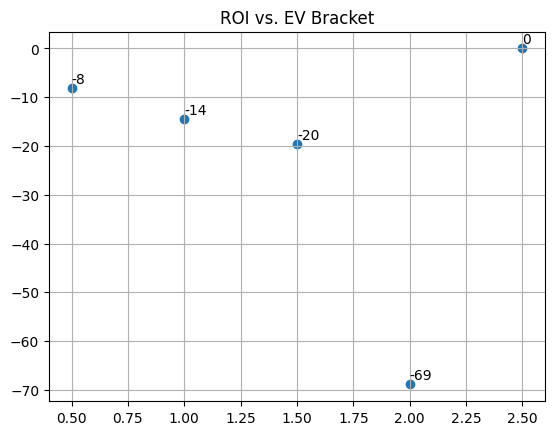

In [64]:
strategy = strategy_flat_elo

results = []

for threshold in [[a, a + 0.5] for a in np.arange(0.5, 3, 0.5)]:
    threshold = [round(t, 2) for t in threshold]
    strategy_name = strategy.__name__
    strategy_name_thresh = f'{strategy_name}_thr{threshold[0]}-{threshold[1]}'
    strategy_betsize_thresh = f'{strategy_name_thresh}_bet_size'
    pdf[strategy_name_thresh] = pdf.apply(lambda row: strategy(row, min_cutoff=threshold[0], max_cutoff=threshold[1])[0], axis=1)
    pdf[strategy_betsize_thresh] = pdf.apply(lambda row: strategy(row, min_cutoff=threshold[0], max_cutoff=threshold[1])[1], axis=1)
    
    number_of_bets = pdf[strategy_betsize_thresh].count()
    net_profit = round(pdf[strategy_name_thresh].sum(), 2)
    try:
        roi = round(pdf[strategy_name_thresh].sum() / pdf[strategy_betsize_thresh].sum() * 100, 2)
    except ZeroDivisionError:
        roi = 0
    print(f'Threshold: {threshold[0]}-{threshold[1]} | Number of bets: {number_of_bets} | Returns: {net_profit} | ROI: {roi}%')

    results.append((threshold[0], net_profit, roi))

offset = 1

plt.figure()
plt.grid(True)
plt.scatter([r[0] for r in results], [r[2] for r in results])

for r in results:
    plt.text(r[0], r[2] + offset, f'{int(round(r[2]))}')

plt.title('ROI vs. EV Bracket')
plt.show()

Threshold: 0.5-1.0 | Number of bets: 551 | Returns: -10.38 | ROI: -4.89%
Threshold: 1.0-1.5 | Number of bets: 2768 | Returns: -108.18 | ROI: -13.47%
Threshold: 1.5-2.0 | Number of bets: 135 | Returns: -6.26 | ROI: -36.26%
Threshold: 2.0-2.5 | Number of bets: 11 | Returns: -0.21 | ROI: -17.2%
Threshold: 2.5-3.0 | Number of bets: 0 | Returns: 0 | ROI: 0%


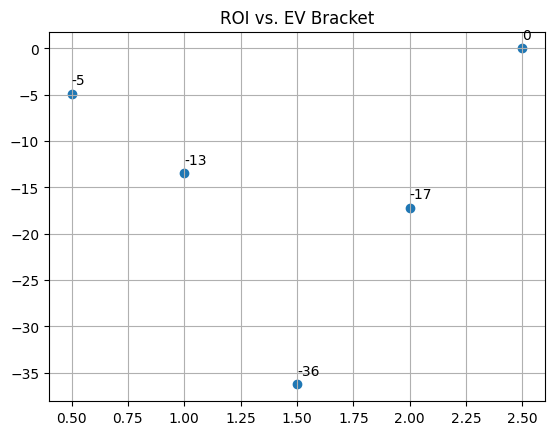

In [65]:
strategy = strategy_dynamic_elo

results = []

for threshold in [[a, a + 0.5] for a in np.arange(0.5, 3, 0.5)]:
    threshold = [round(t, 2) for t in threshold]
    strategy_name = strategy.__name__
    strategy_name_thresh = f'{strategy_name}_thr{threshold[0]}-{threshold[1]}'
    strategy_betsize_thresh = f'{strategy_name_thresh}_bet_size'
    pdf[strategy_name_thresh] = pdf.apply(lambda row: strategy(row, min_cutoff=threshold[0], max_cutoff=threshold[1])[0], axis=1)
    pdf[strategy_betsize_thresh] = pdf.apply(lambda row: strategy(row, min_cutoff=threshold[0], max_cutoff=threshold[1])[1], axis=1)
    
    number_of_bets = pdf[strategy_betsize_thresh].count()
    net_profit = round(pdf[strategy_name_thresh].sum(), 2)
    try:
        roi = round(pdf[strategy_name_thresh].sum() / pdf[strategy_betsize_thresh].sum() * 100, 2)
    except ZeroDivisionError:
        roi = 0
    print(f'Threshold: {threshold[0]}-{threshold[1]} | Number of bets: {number_of_bets} | Returns: {net_profit} | ROI: {roi}%')
    results.append((threshold[0], net_profit, roi))

offset = 1

plt.figure()
plt.grid(True)
plt.scatter([r[0] for r in results], [r[2] for r in results])

for r in results:
    plt.text(r[0], r[2] + offset, f'{int(round(r[2]))}')

plt.title('ROI vs. EV Bracket')
plt.show()

Threshold: 0.5-1.0 | Number of bets: 458 | Returns: -15.75 | ROI: -8.44%
Threshold: 1.0-1.5 | Number of bets: 2485 | Returns: -105.49 | ROI: -14.42%
Threshold: 1.5-2.0 | Number of bets: 135 | Returns: -6.26 | ROI: -36.26%
Threshold: 2.0-2.5 | Number of bets: 11 | Returns: -0.21 | ROI: -17.2%
Threshold: 2.5-3.0 | Number of bets: 0 | Returns: 0 | ROI: 0%


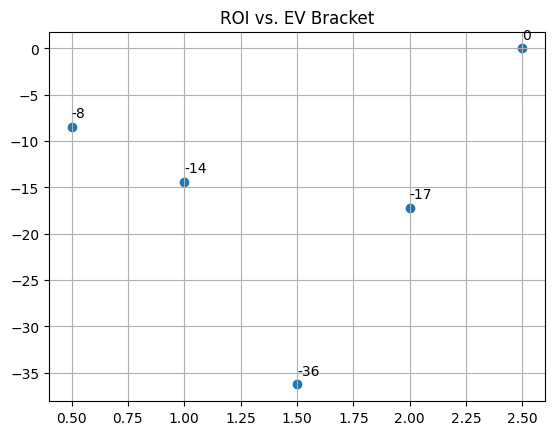

In [66]:
strategy = strategy_dynamic_elo

results = []

pdf_filtered = pdf[pdf['BetPlaced'] != 'D'].copy()

for threshold in [[a, a + 0.5] for a in np.arange(0.5, 3, 0.5)]:
    threshold = [round(t, 2) for t in threshold]
    strategy_name = strategy.__name__
    strategy_name_thresh = f'{strategy_name}_thr{threshold[0]}-{threshold[1]}'
    strategy_betsize_thresh = f'{strategy_name_thresh}_bet_size'
    pdf_filtered[strategy_name_thresh] = pdf_filtered.apply(lambda row: strategy(row, min_cutoff=threshold[0], max_cutoff=threshold[1])[0], axis=1)
    pdf_filtered[strategy_betsize_thresh] = pdf_filtered.apply(lambda row: strategy(row, min_cutoff=threshold[0], max_cutoff=threshold[1])[1], axis=1)
    
    number_of_bets = pdf_filtered[strategy_betsize_thresh].count()
    net_profit = round(pdf_filtered[strategy_name_thresh].sum(), 2)
    try:
        roi = round(pdf_filtered[strategy_name_thresh].sum() / pdf_filtered[strategy_betsize_thresh].sum() * 100, 2)
    except ZeroDivisionError:
        roi = 0
    print(f'Threshold: {threshold[0]}-{threshold[1]} | Number of bets: {number_of_bets} | Returns: {net_profit} | ROI: {roi}%')
    results.append((threshold[0], net_profit, roi))

offset = 1

plt.figure()
plt.grid(True)
plt.scatter([r[0] for r in results], [r[2] for r in results])

for r in results:
    plt.text(r[0], r[2] + offset, f'{int(round(r[2]))}')

plt.title('ROI vs. EV Bracket')
plt.show()

In [67]:
# plt.figure(figsize=(10, 6))
# plt.grid(True)

# pdf_filtered = pdf[(pdf['FTResult'] == 'H') & (pdf['BetPlaced'] == 'H')].copy().reset_index()
# plt.scatter([pdf_filtered['ImpliedProbHome'] for p in pdf_filtered.iterrows()], [pdf_filtered['ProbHome'] for p in pdf_filtered.iterrows()], c='blue', s=2)

# pdf_filtered = pdf[(pdf['FTResult'] == 'D') & (pdf['BetPlaced'] == 'H')].copy().reset_index()
# plt.scatter([pdf_filtered['ImpliedProbHome'] for p in pdf_filtered.iterrows()], [pdf_filtered['ProbHome'] for p in pdf_filtered.iterrows()], c='red', s=2)

# pdf_filtered = pdf[(pdf['FTResult'] == 'A') & (pdf['BetPlaced'] == 'H')].copy().reset_index()
# plt.scatter([pdf_filtered['ImpliedProbHome'] for p in pdf_filtered.iterrows()], [pdf_filtered['ProbHome'] for p in pdf_filtered.iterrows()], c='green', s=2)

# plt.xlabel('Implied Probability Home Win')
# plt.ylabel('Model-predicted Probability Home Win')
# plt.show()

In [68]:
pdf.to_csv('data/tmp_betting_backtest_results_with_opta.csv', index=False)